In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.style.use("seaborn-v0_8-colorblind")

matplotlib.rcParams.update({'font.size': 24})

In [2]:
def results_to_df(results_list, dataset, sampling_method, bsl=False):
    res = []
    for config in results_list:
        b = config["b"]
        if (b == 1 or b == 0) and sampling_method != "baseline" and not bsl:
            continue
            
        if sampling_method.endswith("_dp"):
            e = config["e"]
        else:
            e = np.inf
        test_bacc = config["test_bacc"]
        e = config["e"]
        res.append((dataset, sampling_method, e, b, test_bacc))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "sampling", "e", "b", "test_bacc"])

def add_baseline(results_df, method, e):
    bsl = results_df[(results_df["sampling"] == "baseline") & ((results_df["e"] == np.inf) | (results_df["e"] == e))]
    method = results_df[(results_df["sampling"] == method) & (results_df["e"] == e)]
    method = pd.concat([bsl, method]).sort_values(by=["e", "b"], ascending=False)
    return method

def read_data(dataset):
    PATH = dataset + "/"
    with open(PATH + "attacker.baseline", "rb") as f:
        baseline_results = pkl.load(f)
        baseline_results_df = results_to_df(baseline_results, dataset, "baseline")
    with open(PATH + "attacker.random_dp", "rb") as f:
        results = pkl.load(f)
        random_dp_df = results_to_df(results, dataset, "random_dp")
    with open(PATH + "attacker.ister_dp", "rb") as f:
        results = pkl.load(f)
        ister_dp_df = results_to_df(results, dataset, "ister_dp")
    results_df = pd.concat([baseline_results_df, random_dp_df, ister_dp_df]).reset_index(drop=True)
    
    return results_df

def read_stereo_data(dataset):
    PATH = dataset + "/"
    with open(PATH + "attacker.only_stereo.baseline", "rb") as f:
        baseline_results = pkl.load(f)
        baseline_results_df = results_to_df(baseline_results, dataset, "baseline")
    with open(PATH + "attacker.only_stereo.random_dp", "rb") as f:
        results = pkl.load(f)
        random_dp_df = results_to_df(results, dataset, "random_dp")
    with open(PATH + "attacker.only_stereo.ister_dp", "rb") as f:
        results = pkl.load(f)
        ister_dp_df = results_to_df(results, dataset, "ister_dp")
    results_df = pd.concat([baseline_results_df, random_dp_df, ister_dp_df]).reset_index(drop=True)
    
    return results_df

In [3]:
ml1m_results_df = read_data("ml1m")
bx_results_df = read_data("bx")
#ambar_results_df = read_data("ambar")

In [4]:
bsl = ml1m_results_df[(ml1m_results_df["b"] == 1)]["test_bacc"].values
print(bsl)
df = ml1m_results_df[(ml1m_results_df["b"] == 0)]
df["rel_bacc"] = 100*(df["test_bacc"] - bsl) / bsl
print(df)

bsl = ml1m_results_df[(ml1m_results_df["b"] == 1)]["test_bacc"].values
print(bsl)
df = ml1m_results_df[(ml1m_results_df["b"] == 0)]
df["rel_bacc"] = 100*(df["test_bacc"] - bsl) / bsl
print(df)

[0.7428967]
  dataset  sampling    e    b  test_bacc  rel_bacc
1    ml1m  baseline  3.0  0.0   0.743791  0.120441
2    ml1m  baseline  2.0  0.0   0.738977 -0.527621
3    ml1m  baseline  1.0  0.0   0.727114 -2.124484
4    ml1m  baseline  0.1  0.0   0.717591 -3.406292
[0.7428967]
  dataset  sampling    e    b  test_bacc  rel_bacc
1    ml1m  baseline  3.0  0.0   0.743791  0.120441
2    ml1m  baseline  2.0  0.0   0.738977 -0.527621
3    ml1m  baseline  1.0  0.0   0.727114 -2.124484
4    ml1m  baseline  0.1  0.0   0.717591 -3.406292


C:\Users\pmuellner\AppData\Local\Temp\ipykernel_24468\693362920.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["rel_bacc"] = 100*(df["test_bacc"] - bsl) / bsl
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_24468\693362920.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["rel_bacc"] = 100*(df["test_bacc"] - bsl) / bsl


In [5]:
bsl = bx_results_df[(bx_results_df["b"] == 1)]["test_bacc"].values
print(bsl)
df = bx_results_df[(bx_results_df["b"] == 0)]
df["rel_bacc"] = 100*(df["test_bacc"] - bsl) / bsl
print(df)

bsl = bx_results_df[(bx_results_df["b"] == 1)]["test_bacc"].values
print(bsl)
df = bx_results_df[(bx_results_df["b"] == 0)]
df["rel_bacc"] = 100*(df["test_bacc"] - bsl) / bsl
print(df)

[0.65817357]
  dataset  sampling    e    b  test_bacc  rel_bacc
1      bx  baseline  3.0  0.0   0.649834 -1.267024
2      bx  baseline  2.0  0.0   0.663039  0.739246
3      bx  baseline  1.0  0.0   0.639665 -2.812083
4      bx  baseline  0.1  0.0   0.641873 -2.476712
[0.65817357]
  dataset  sampling    e    b  test_bacc  rel_bacc
1      bx  baseline  3.0  0.0   0.649834 -1.267024
2      bx  baseline  2.0  0.0   0.663039  0.739246
3      bx  baseline  1.0  0.0   0.639665 -2.812083
4      bx  baseline  0.1  0.0   0.641873 -2.476712


C:\Users\pmuellner\AppData\Local\Temp\ipykernel_24468\1631635037.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["rel_bacc"] = 100*(df["test_bacc"] - bsl) / bsl
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_24468\1631635037.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["rel_bacc"] = 100*(df["test_bacc"] - bsl) / bsl


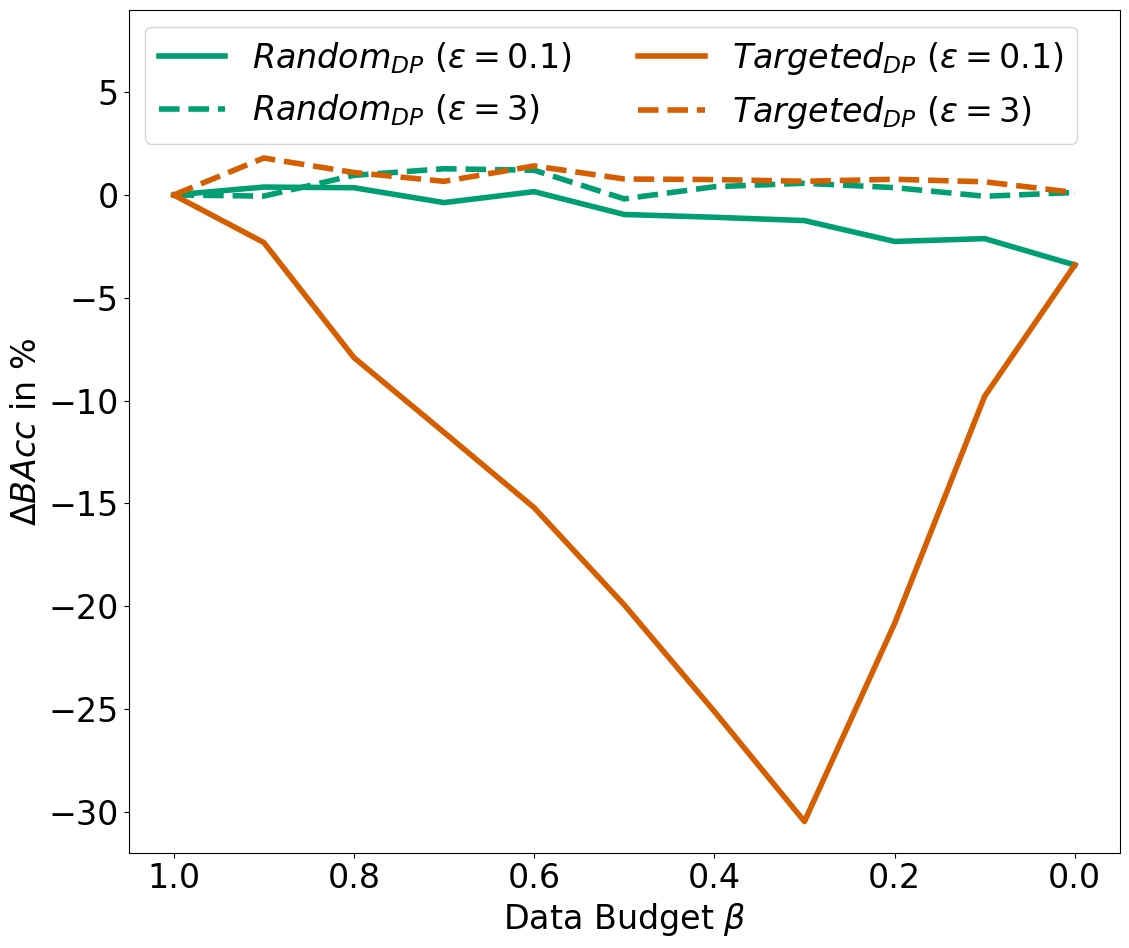

In [6]:
%matplotlib inline
plt.figure(figsize=(12, 10))

random01 = add_baseline(ml1m_results_df, method="random_dp", e=0.1)
random3 = add_baseline(ml1m_results_df, method="random_dp", e=3)
bsl_nodp = random01[random01["b"] == 1.0]["test_bacc"].values
plt.plot(random01["b"], 100*(random01["test_bacc"] - bsl_nodp) / bsl_nodp, label=r"$Random_{DP}\ (\epsilon=0.1)$", c="C1", linewidth=4)
plt.plot(random3["b"], 100*(random3["test_bacc"] - bsl_nodp) / bsl_nodp, label=r"$Random_{DP}\ (\epsilon=3)$", c="C1", linestyle="dashed", linewidth=4)

ister01 = add_baseline(ml1m_results_df, method="ister_dp", e=0.1)
ister3 = add_baseline(ml1m_results_df, method="ister_dp", e=3)
plt.plot(ister01["b"], 100*(ister01["test_bacc"] - bsl_nodp) / bsl_nodp, label=r"$Targeted_{DP}\ (\epsilon=0.1$)", c="C2", linewidth=4)
plt.plot(ister3["b"], 100*(ister3["test_bacc"] - bsl_nodp) / bsl_nodp, label=r"$Targeted_{DP}\ (\epsilon=3$)", c="C2", linestyle="dashed", linewidth=4)

plt.gca().invert_xaxis()
plt.legend(ncol=2, loc="upper left")
plt.ylabel(r"$\Delta BAcc$ in $\%$")
plt.xlabel(r"Data Budget $\beta$")
plt.ylim([-32, 9])
plt.tight_layout()
plt.savefig("figures/ml1m_attacker.png", dpi=300)

In [7]:
print(ister01.loc[ister01["test_bacc"].idxmin()]["b"])
bsl = random01.iloc[-1]["test_bacc"]
print((ister01["test_bacc"].min() - bsl) / bsl)

0.3
-0.280296239833812


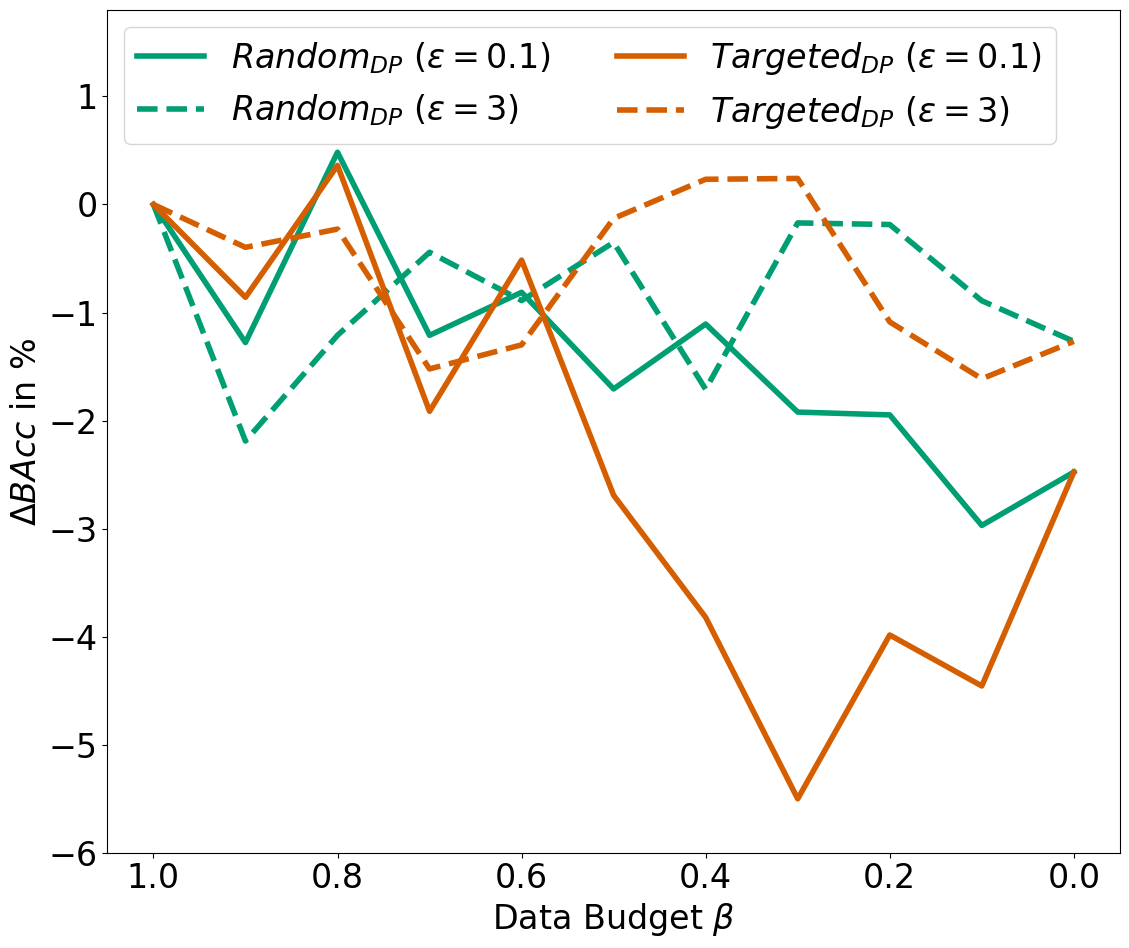

In [8]:
plt.figure(figsize=(12, 10))

random01 = add_baseline(bx_results_df, method="random_dp", e=0.1)
random3 = add_baseline(bx_results_df, method="random_dp", e=3)
bsl_nodp = random01[random01["b"] == 1.0]["test_bacc"].values
plt.plot(random01["b"], 100*(random01["test_bacc"] - bsl_nodp) / bsl_nodp, label=r"$Random_{DP}\ (\epsilon=0.1)$", c="C1", linewidth=4)
plt.plot(random3["b"], 100*(random3["test_bacc"] - bsl_nodp) / bsl_nodp, label=r"$Random_{DP}\ (\epsilon=3)$", c="C1", linestyle="dashed", linewidth=4)

ister01 = add_baseline(bx_results_df, method="ister_dp", e=0.1)
ister3 = add_baseline(bx_results_df, method="ister_dp", e=3)
plt.plot(ister01["b"], 100*(ister01["test_bacc"] - bsl_nodp) / bsl_nodp, label=r"$Targeted_{DP}\ (\epsilon=0.1$)", c="C2", linewidth=4)
plt.plot(ister3["b"], 100*(ister3["test_bacc"] - bsl_nodp) / bsl_nodp, label=r"$Targeted_{DP}\ (\epsilon=3$)", c="C2", linestyle="dashed", linewidth=4)

plt.gca().invert_xaxis()
plt.legend(ncol=2, loc="upper left")
plt.ylabel(r"$\Delta BAcc$ in $\%$")
plt.xlabel(r"Data Budget $\beta$")
plt.ylim([-6, 1.8])
plt.tight_layout()
plt.savefig("figures/bx_attacker.png", dpi=300)

In [9]:
print(ister01.loc[ister01["test_bacc"].idxmin()]["b"])
bsl = random01.iloc[-1]["test_bacc"]
print((ister01["test_bacc"].min() - bsl) / bsl)

0.3
-0.03101101908182462


In [10]:
random01 = add_baseline(ambar_results_df, method="random_dp", e=0.1)
random3 = add_baseline(ambar_results_df, method="random_dp", e=3)
plt.plot(random01["b"], random01["test_bacc"], label=r"Rand. $\epsilon=0.1$", c="C1")
plt.plot(random3["b"], random3["test_bacc"], label=r"Rand. $\epsilon=3$", c="C1", linestyle="dashed")

ister01 = add_baseline(ambar_results_df, method="ister_dp", e=0.1)
ister3 = add_baseline(ambar_results_df, method="ister_dp", e=3)
plt.plot(ister01["b"], ister01["test_bacc"], label=r"Stereo $\epsilon=0.1$", c="C2")
plt.plot(ister3["b"], ister3["test_bacc"], label=r"Stereo $\epsilon=3$", c="C2", linestyle="dashed")

plt.gca().invert_xaxis()
#plt.title("BAcc.")
plt.legend(ncol=2)
plt.ylabel("BAcc.")
plt.xlabel("Data Budget")
#plt.ylim([0.54, 0.68])
plt.show()

NameError: name 'ambar_results_df' is not defined

In [11]:
print(ister01.loc[ister01["test_bacc"].idxmin()]["b"])
bsl = random01.iloc[-1]["test_bacc"]
print((ister01["test_bacc"].min() - bsl) / bsl)

0.3
-0.03101101908182462


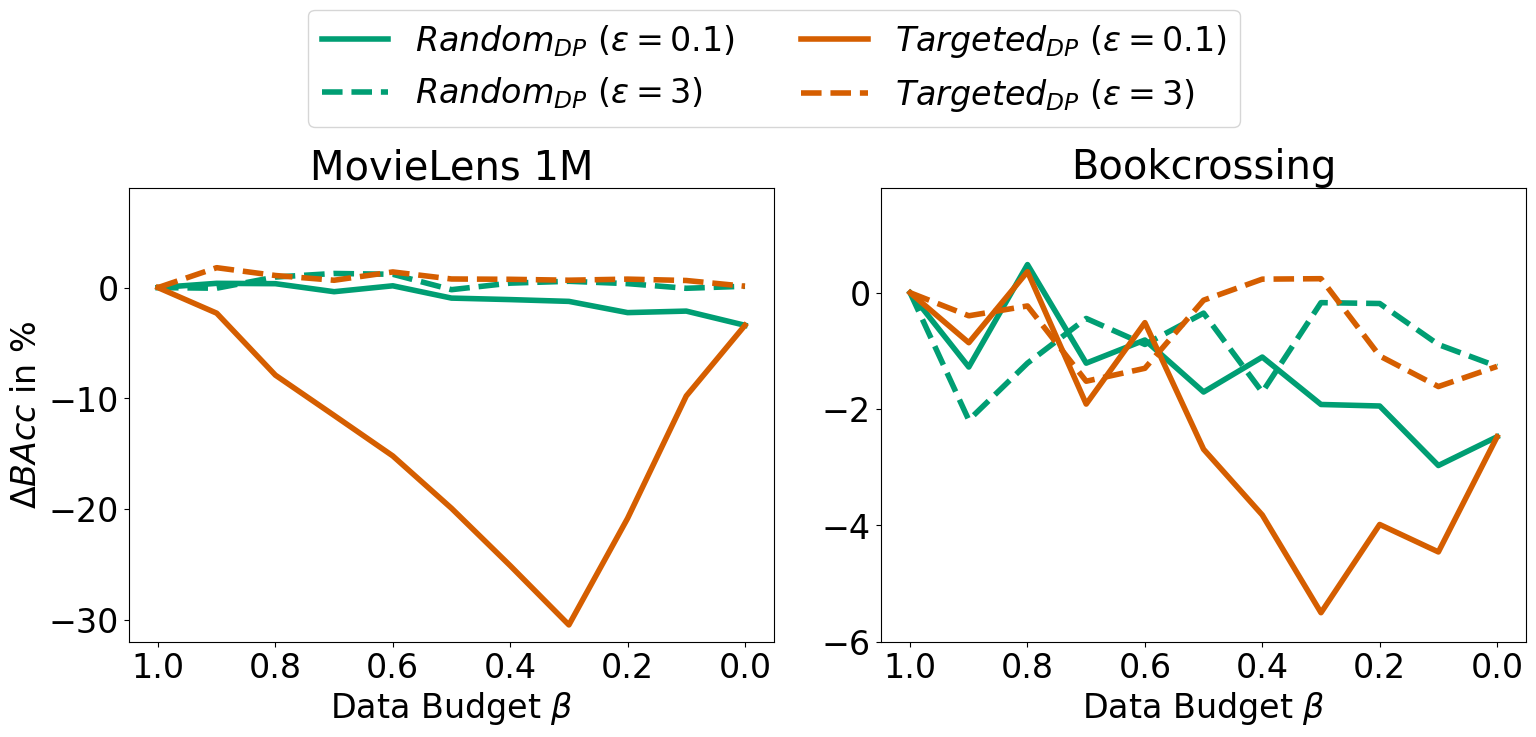

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ------------------ LEFT: ML1M ------------------
ax = axes[0]

random01 = add_baseline(ml1m_results_df, method="random_dp", e=0.1)
random3 = add_baseline(ml1m_results_df, method="random_dp", e=3)
bsl_nodp = random01[random01["b"] == 1.0]["test_bacc"].values

l1, = ax.plot(random01["b"], 100*(random01["test_bacc"] - bsl_nodp) / bsl_nodp,
              label=r"$Random_{DP}\ (\epsilon=0.1)$", c="C1", linewidth=4)

l2, = ax.plot(random3["b"], 100*(random3["test_bacc"] - bsl_nodp) / bsl_nodp,
              label=r"$Random_{DP}\ (\epsilon=3)$", c="C1", linestyle="dashed", linewidth=4)

ister01 = add_baseline(ml1m_results_df, method="ister_dp", e=0.1)
ister3 = add_baseline(ml1m_results_df, method="ister_dp", e=3)

l3, = ax.plot(ister01["b"], 100*(ister01["test_bacc"] - bsl_nodp) / bsl_nodp,
              label=r"$Targeted_{DP}\ (\epsilon=0.1)$", c="C2", linewidth=4)

l4, = ax.plot(ister3["b"], 100*(ister3["test_bacc"] - bsl_nodp) / bsl_nodp,
              label=r"$Targeted_{DP}\ (\epsilon=3)$", c="C2", linestyle="dashed", linewidth=4)

ax.invert_xaxis()
ax.set_title("MovieLens 1M")
ax.set_xlabel(r"Data Budget $\beta$")
ax.set_ylabel(r"$\Delta BAcc$ in $\%$")
ax.set_ylim([-32, 9])


# ------------------ RIGHT: BX ------------------
ax = axes[1]

random01 = add_baseline(bx_results_df, method="random_dp", e=0.1)
random3 = add_baseline(bx_results_df, method="random_dp", e=3)
bsl_nodp = random01[random01["b"] == 1.0]["test_bacc"].values

ax.plot(random01["b"], 100*(random01["test_bacc"] - bsl_nodp) / bsl_nodp,
        c="C1", linewidth=4)

ax.plot(random3["b"], 100*(random3["test_bacc"] - bsl_nodp) / bsl_nodp,
        c="C1", linestyle="dashed", linewidth=4)

ister01 = add_baseline(bx_results_df, method="ister_dp", e=0.1)
ister3 = add_baseline(bx_results_df, method="ister_dp", e=3)

ax.plot(ister01["b"], 100*(ister01["test_bacc"] - bsl_nodp) / bsl_nodp,
        c="C2", linewidth=4)

ax.plot(ister3["b"], 100*(ister3["test_bacc"] - bsl_nodp) / bsl_nodp,
        c="C2", linestyle="dashed", linewidth=4)

ax.invert_xaxis()
ax.set_title("Bookcrossing")
ax.set_xlabel(r"Data Budget $\beta$")
ax.set_ylim([-6, 1.8])


# ------------------ SHARED LEGEND ------------------
fig.legend([l1, l2, l3, l4],
           [l.get_label() for l in [l1, l2, l3, l4]],
           loc="upper center",
           ncol=2,
           bbox_to_anchor=(0.5, 1.1))

# leave space for legend
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig("figures/combined_attacker.png", dpi=300, bbox_inches="tight")
plt.show()

# only stereo users

In [206]:
ml1m_results_df = read_stereo_data("ml1m")
bx_results_df = read_stereo_data("bx")
ambar_results_df = read_stereo_data("ambar")

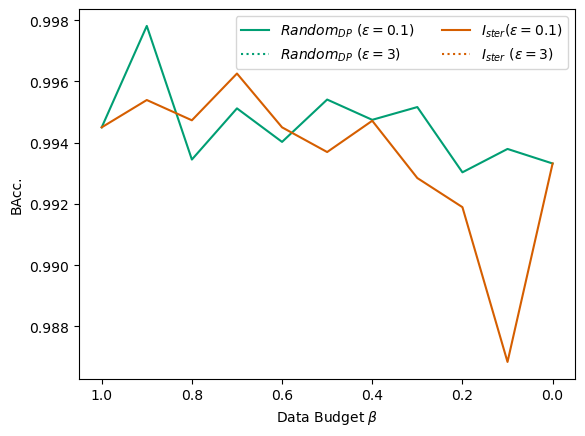

In [208]:
random01 = add_baseline(ml1m_results_df, method="random_dp", e=0.1)
random3 = add_baseline(ml1m_results_df, method="random_dp", e=3)
plt.plot(random01["b"], random01["test_bacc"], label=r"$Random_{DP}\ (\epsilon=0.1)$", c="C1")
plt.plot(random3["b"], random3["test_bacc"], label=r"$Random_{DP}\ (\epsilon=3)$", c="C1", linestyle="dotted")

ister01 = add_baseline(ml1m_results_df, method="ister_dp", e=0.1)
ister3 = add_baseline(ml1m_results_df, method="ister_dp", e=3)
plt.plot(ister01["b"], ister01["test_bacc"], label=r"$I_{ster} (\epsilon=0.1$)", c="C2")
plt.plot(ister3["b"], ister3["test_bacc"], label=r"$I_{ster}\ (\epsilon=3$)", c="C2", linestyle="dotted")

plt.gca().invert_xaxis()
#plt.title("BAcc.")
plt.legend(ncol=2, loc="upper right")
plt.ylabel("BAcc.")
plt.xlabel(r"Data Budget $\beta$")
#plt.ylim([0.5, .85])
plt.show()

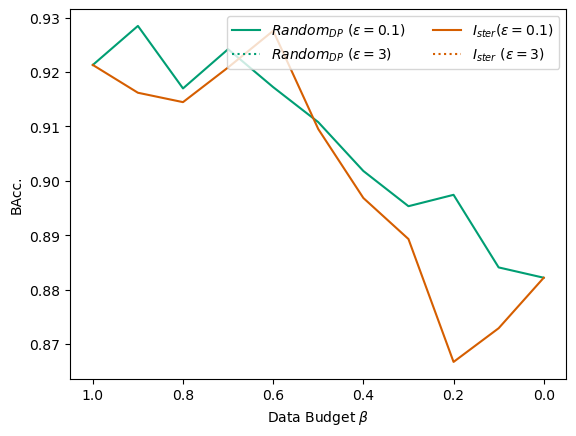

In [209]:
random01 = add_baseline(bx_results_df, method="random_dp", e=0.1)
random3 = add_baseline(bx_results_df, method="random_dp", e=3)
plt.plot(random01["b"], random01["test_bacc"], label=r"$Random_{DP}\ (\epsilon=0.1)$", c="C1")
plt.plot(random3["b"], random3["test_bacc"], label=r"$Random_{DP}\ (\epsilon=3)$", c="C1", linestyle="dotted")

ister01 = add_baseline(bx_results_df, method="ister_dp", e=0.1)
ister3 = add_baseline(bx_results_df, method="ister_dp", e=3)
plt.plot(ister01["b"], ister01["test_bacc"], label=r"$I_{ster} (\epsilon=0.1$)", c="C2")
plt.plot(ister3["b"], ister3["test_bacc"], label=r"$I_{ster}\ (\epsilon=3$)", c="C2", linestyle="dotted")

plt.gca().invert_xaxis()
#plt.title("BAcc.")
plt.legend(ncol=2, loc="upper right")
plt.ylabel("BAcc.")
plt.xlabel(r"Data Budget $\beta$")
#plt.ylim([0.62, .68])
plt.show()

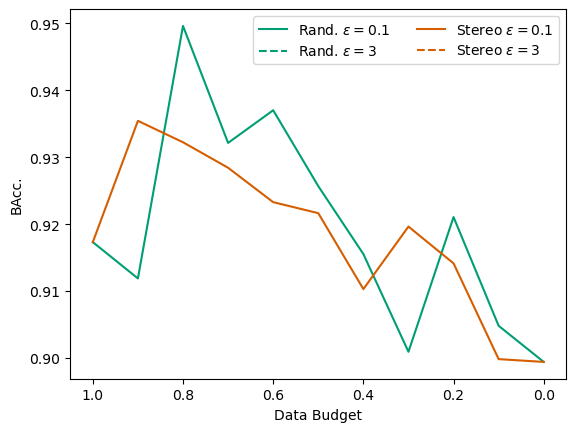

In [210]:
random01 = add_baseline(ambar_results_df, method="random_dp", e=0.1)
random3 = add_baseline(ambar_results_df, method="random_dp", e=3)
plt.plot(random01["b"], random01["test_bacc"], label=r"Rand. $\epsilon=0.1$", c="C1")
plt.plot(random3["b"], random3["test_bacc"], label=r"Rand. $\epsilon=3$", c="C1", linestyle="dashed")

ister01 = add_baseline(ambar_results_df, method="ister_dp", e=0.1)
ister3 = add_baseline(ambar_results_df, method="ister_dp", e=3)
plt.plot(ister01["b"], ister01["test_bacc"], label=r"Stereo $\epsilon=0.1$", c="C2")
plt.plot(ister3["b"], ister3["test_bacc"], label=r"Stereo $\epsilon=3$", c="C2", linestyle="dashed")

plt.gca().invert_xaxis()
#plt.title("BAcc.")
plt.legend(ncol=2)
plt.ylabel("BAcc.")
plt.xlabel("Data Budget")
#plt.ylim([0.54, 0.68])
plt.show()